# Perfil y subordinados

## Objetivo
Analizar las características del personal que ha sido entrevistado debido a procesos de rotación, identificando patrones en variables demográficas, organizacionales y de gestión de equipo que puedan proporcionar insights relevantes sobre los perfiles de los entrevistados.

## 1. Configuración del Entorno

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

## 2. Carga y Preparación de Datos

In [ ]:
# Cargar datos
df = pd.read_csv('../data/df_entrevistados_rotacion.csv', encoding='utf-8')

# Información general
print(f"Dimensiones del dataset: {df.shape}")
print(f"\nNúmero de registros: {len(df):,}")
print(f"Número de variables: {len(df.columns)}")

Dimensiones del dataset: (4670, 41)

Número de registros: 4,670
Número de variables: 41


In [ ]:
# Estructura de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4670 entries, 0 to 4669
Data columns (total 41 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   num_empleado                           4670 non-null   int64  
 1   escolaridad                            4670 non-null   object 
 2   numero_de_persona                      4670 non-null   int64  
 3   numero_de_trabajador                   4670 non-null   int64  
 4   nombre_de_colaborador                  4670 non-null   object 
 5   tipo_rol                               4670 non-null   object 
 6   tiene_subordinados                     4670 non-null   bool   
 7   fecha_antiguedad_grupo                 4670 non-null   object 
 8   centro_de_costos                       4670 non-null   object 
 9   centro                                 4670 non-null   int64  
 10  ubicacion                              4670 non-null   object 
 11  regi

In [ ]:
# Conversión de fecha_antiguedad_grupo a datetime
df['fecha_antiguedad_grupo'] = pd.to_datetime(df['fecha_antiguedad_grupo'], format='%d/%m/%Y', errors='coerce')

# Crear variable de años de antigüedad calculados
fecha_corte = pd.to_datetime('2025-09-30')
df['antiguedad_calculada_anos'] = (fecha_corte - df['fecha_antiguedad_grupo']).dt.days / 365.25

## 3. Análisis Descriptivo General

In [ ]:
# Estadísticas descriptivas de variables numéricas clave
variables_numericas = ['antiguedad_anois', 'tamano_equipo', 'pct_ocupacion_equipo', 
                       'promedio_antiguedad_subordinados_anos', 'total_plantilla_autorizada',
                       'posiciones_vacantes', 'pct_posiciones_vacantes']

df[variables_numericas].describe().round(2)

,antiguedad_anois,tamano_equipo,pct_ocupacion_equipo,promedio_antiguedad_subordinados_anos,total_plantilla_autorizada,posiciones_vacantes,pct_posiciones_vacantes
count,4670.00,4670.00,4670.00,3643.00,4670.00,4670.00,4670.00
mean,8.51,11.33,51.88,3.63,18.15,11.33,60.93
std,5.83,10.06,31.90,2.33,15.72,10.06,36.00
min,-0.12,0.00,0.00,0.06,0.00,0.00,0.00
25%,3.68,4.00,37.84,2.18,5.00,4.00,47.53
50%,7.72,11.00,57.14,3.11,17.00,11.00,69.23
75%,12.27,15.00,75.00,4.37,26.00,15.00,90.91
max,35.92,128.00,100.00,22.64,161.00,128.00,200.00


## 4. Análisis por Perfil Demográfico y Educativo

### 4.1. Distribución por Nivel de Escolaridad

In [6]:
# Distribución de escolaridad
escolaridad_dist = df['escolaridad'].value_counts()
escolaridad_pct = df['escolaridad'].value_counts(normalize=True) * 100

print("Distribución de Personal por Nivel de Escolaridad:")
print("="*60)
for nivel, count in escolaridad_dist.items():
    pct = escolaridad_pct[nivel]
    print(f"{nivel:30s}: {count:5d} ({pct:5.2f}%)")

Distribución de Personal por Nivel de Escolaridad:
Licenciatura o Ingeniería     :  3453 (73.94%)
Preparatoria                  :   531 (11.37%)
Maestría                      :   355 ( 7.60%)
Carrera técnica               :   227 ( 4.86%)
Preparatoria, Carrera técnica :    28 ( 0.60%)
Licenciatura o Ingeniería, Maestría:    23 ( 0.49%)
Carrera técnica, Licenciatura o Ingeniería:    20 ( 0.43%)
Preparatoria, Licenciatura o Ingeniería:    17 ( 0.36%)
Doctorado                     :     6 ( 0.13%)
Preparatoria, Carrera técnica, Licenciatura o Ingeniería:     5 ( 0.11%)
Preparatoria, Carrera técnica, Licenciatura o Ingeniería, Maestría:     1 ( 0.02%)
Preparatoria, Doctorado       :     1 ( 0.02%)
Carrera técnica, Maestría     :     1 ( 0.02%)
Licenciatura o Ingeniería, Doctorado:     1 ( 0.02%)
Maestría, Doctorado           :     1 ( 0.02%)


### 4.2. Análisis por Tipo de Rol Organizacional

In [7]:
# Distribución por tipo de rol
tipo_rol_dist = df['tipo_rol'].value_counts()
tipo_rol_pct = df['tipo_rol'].value_counts(normalize=True) * 100

print("Distribución de Personal por Tipo de Rol:")
print("="*70)
for rol, count in tipo_rol_dist.items():
    pct = tipo_rol_pct[rol]
    print(f"{rol:40s}: {count:5d} ({pct:5.2f}%)")

Distribución de Personal por Tipo de Rol:
Manager con equipo y vacantes           :  3682 (78.84%)
Sin subordinados                        :   988 (21.16%)


In [8]:
df[df['tipo_rol']=='Sin subordinados'].head()  # Visualizar algunos registros

,num_empleado,escolaridad,numero_de_persona,numero_de_trabajador,nombre_de_colaborador,tipo_rol,tiene_subordinados,fecha_antiguedad_grupo,centro_de_costos,centro,ubicacion,region,ciudad,empleador_legal,unidad_de_negocio,division,departamento,codigo_de_puesto,nombre_de_puesto,familia_de_puesto,funcion_del_puesto,codigo_de_posicion,nombre_de_posicion,total_plantilla_autorizada,posiciones_vacantes,total_contrataciones_congeladas,total_contrataciones_aprobadas,total_posiciones_presupuestadas,totaL_indefinidos_a_cargo,lista_subordinados_trabajador,grupos_salariales,promedio_grupo_salarial,std_grupo_salarial,moda_grupo_salarial,promedio_antiguedad_subordinados_anos,std_antiguedad_equipo,antiguedad_anois,tamano_equipo,pct_ocupacion_equipo,indice_rigidez_contratacion,pct_posiciones_vacantes,antiguedad_calculada_anos
23,90016968,Licenciatura o Ingeniería,90016968,90016968,Ángel Hernández Espíndola,Sin subordinados,False,2024-09-13,095 - GERENTE GENERAL,777510,MX-01-TLAX-1586 - T08-PUENTE-1586,PUEBLA,"PAPALOTLA, TLX",COPPEL SA DE CV,BU_CSACV,DIRECCION DE OPERACIONES DE GC,06 OPERACION TIENDA 7775 PUENTE,36,GERENTE SUPLENTE,Manager,GERENTE,140154,GERENTE SUPLENTE,0,0,0,0,0,0,[],NaN,NaN,NaN,NaN,NaN,NaN,1.11,0,0.00,0.00,0.00,1.05
24,90240402,Maestría,90240402,90240402,Jose Osvaldo Hernandez Lopez,Sin subordinados,False,2022-05-30,015 - ZONAS,316602,MX-05-MEX-40 - R27-OFICINA STAFF-COPPEL-40,TEXCOCO,TEXCOCO EDO MEX,COPPEL SA DE CV,BU_CSACV,DIRECCION DE OPERACIONES DE GC,05 OPERACION 08 TIENDA TXCC,36,GERENTE SUPLENTE,Manager,GERENTE,137181,GERENTE SUPLENTE,0,0,0,0,0,0,[],NaN,NaN,NaN,NaN,NaN,NaN,3.40,0,0.00,0.00,0.00,3.34
27,90360675,Licenciatura o Ingeniería,90360675,90360675,David Jonatan Mendoza Mireles,Sin subordinados,False,2023-11-21,001 - TDAS MUEBLES,85701,MX-01-TAMPS-781 - T22-HIDALGO-781,MONTERREY II,"REYNOSA, TAM.",COPPEL SA DE CV,BU_CSACV,DIRECCION DE OPERACIONES DE GC,07 TIENDA MUEBLES 0857 HIDALGO,36,GERENTE SUPLENTE,Manager,GERENTE,130028,GERENTE SUPLENTE,0,0,0,0,0,0,[],NaN,NaN,NaN,NaN,NaN,NaN,1.92,0,0.00,0.00,0.00,1.86
28,90393419,Licenciatura o Ingeniería,100024241,90393419,Bianca Jacqueline Gomez Mitchel,Sin subordinados,False,2024-08-14,095 - GERENTE GENERAL,793810,MX-02-BCS-40 - T15-CEDIS SJCB-40,LOS MOCHIS,CABO SAN LUCAS,COPPEL SA DE CV,BU_CSACV,DIRECCION DE OPERACIONES DE GC,06 OPERACION TIENDA 7938 PASEO PACIFICO,36,GERENTE SUPLENTE,Manager,GERENTE,141183,GERENTE SUPLENTE,0,0,0,0,0,0,[],NaN,NaN,NaN,NaN,NaN,NaN,1.19,0,0.00,0.00,0.00,1.13
40,96842211,Licenciatura o Ingeniería,96842211,96842211,Maria Sanjuana Cabrera Coronado,Sin subordinados,False,2022-10-03,015 - ZONAS,342001,MX-01-JAL-1001 - T27-RAMIREZ-1001,LEON II,SAN MIGUEL EL ALTO,COPPEL SA DE CV,BU_CSACV,DIRECCION DE OPERACIONES DE GC,05 OPERACION 11 TIENDA LEON,36,GERENTE SUPLENTE,Manager,GERENTE,97737,GERENTE SUPLENTE,0,0,0,0,0,0,[],NaN,NaN,NaN,NaN,NaN,NaN,3.62,0,0.00,0.00,0.00,2.99


## 5. Análisis de Antigüedad Organizacional

### 5.1. Distribución de Antigüedad

In [9]:
# Estadísticas de antigüedad
print("Estadísticas de Antigüedad (años):")
print("="*50)
print(f"Media:           {df['antiguedad_anois'].mean():.2f} años")
print(f"Mediana:         {df['antiguedad_anois'].median():.2f} años")
print(f"Desviación Est.: {df['antiguedad_anois'].std():.2f} años")
print(f"Mínimo:          {df['antiguedad_anois'].min():.2f} años")
print(f"Máximo:          {df['antiguedad_anois'].max():.2f} años")

# Categorizar antigüedad
df['rango_antiguedad'] = pd.cut(df['antiguedad_anois'], 
                                 bins=[0, 2, 5, 10, 15, 100],
                                 labels=['0-2 años', '2-5 años', '5-10 años', '10-15 años', '15+ años'])

antiguedad_rangos = df['rango_antiguedad'].value_counts().sort_index()
print("\nDistribución por Rangos de Antigüedad:")
print("="*50)
for rango, count in antiguedad_rangos.items():
    pct = (count / len(df)) * 100
    print(f"{rango:15s}: {count:5d} ({pct:5.2f}%)")

Estadísticas de Antigüedad (años):
Media:           8.51 años
Mediana:         7.72 años
Desviación Est.: 5.83 años
Mínimo:          -0.12 años
Máximo:          35.92 años

Distribución por Rangos de Antigüedad:
0-2 años       :   646 (13.83%)
2-5 años       :   893 (19.12%)
5-10 años      :  1384 (29.64%)
10-15 años     :  1063 (22.76%)
15+ años       :   679 (14.54%)


## 6. Análisis de Gestión de Equipos

### 6.1. Tamaño de Equipos y Ocupación

In [10]:
# Filtrar solo managers con equipo
managers_con_equipo = df[df['tiene_subordinados'] == True].copy()

print(f"Total de Managers con Equipos: {len(managers_con_equipo):,}")
print("\nEstadísticas de Tamaño de Equipo:")
print("="*50)
print(f"Promedio:        {managers_con_equipo['tamano_equipo'].mean():.2f} subordinados")
print(f"Mediana:         {managers_con_equipo['tamano_equipo'].median():.0f} subordinados")
print(f"Desviación Est.: {managers_con_equipo['tamano_equipo'].std():.2f}")
print(f"Mínimo:          {managers_con_equipo['tamano_equipo'].min():.0f} subordinados")
print(f"Máximo:          {managers_con_equipo['tamano_equipo'].max():.0f} subordinados")

Total de Managers con Equipos: 3,682

Estadísticas de Tamaño de Equipo:
Promedio:        14.37 subordinados
Mediana:         13 subordinados
Desviación Est.: 9.20
Mínimo:          0 subordinados
Máximo:          128 subordinados


In [11]:
# Categorizar tamaño de equipo
managers_con_equipo['rango_tamano_equipo'] = pd.cut(managers_con_equipo['tamano_equipo'], 
                                                     bins=[0, 5, 10, 20, 50, 200],
                                                     labels=['1-5', '6-10', '11-20', '21-50', '51+'])

tamano_dist = managers_con_equipo['rango_tamano_equipo'].value_counts().sort_index()

print("\nDistribución por Tamaño de Equipo:")
print("="*50)
for rango, count in tamano_dist.items():
    pct = (count / len(managers_con_equipo)) * 100
    print(f"{rango} subordinados: {count:5d} ({pct:5.2f}%)")


Distribución por Tamaño de Equipo:
1-5 subordinados:   353 ( 9.59%)
6-10 subordinados:   755 (20.51%)
11-20 subordinados:  1987 (53.97%)
21-50 subordinados:   522 (14.18%)
51+ subordinados:    27 ( 0.73%)


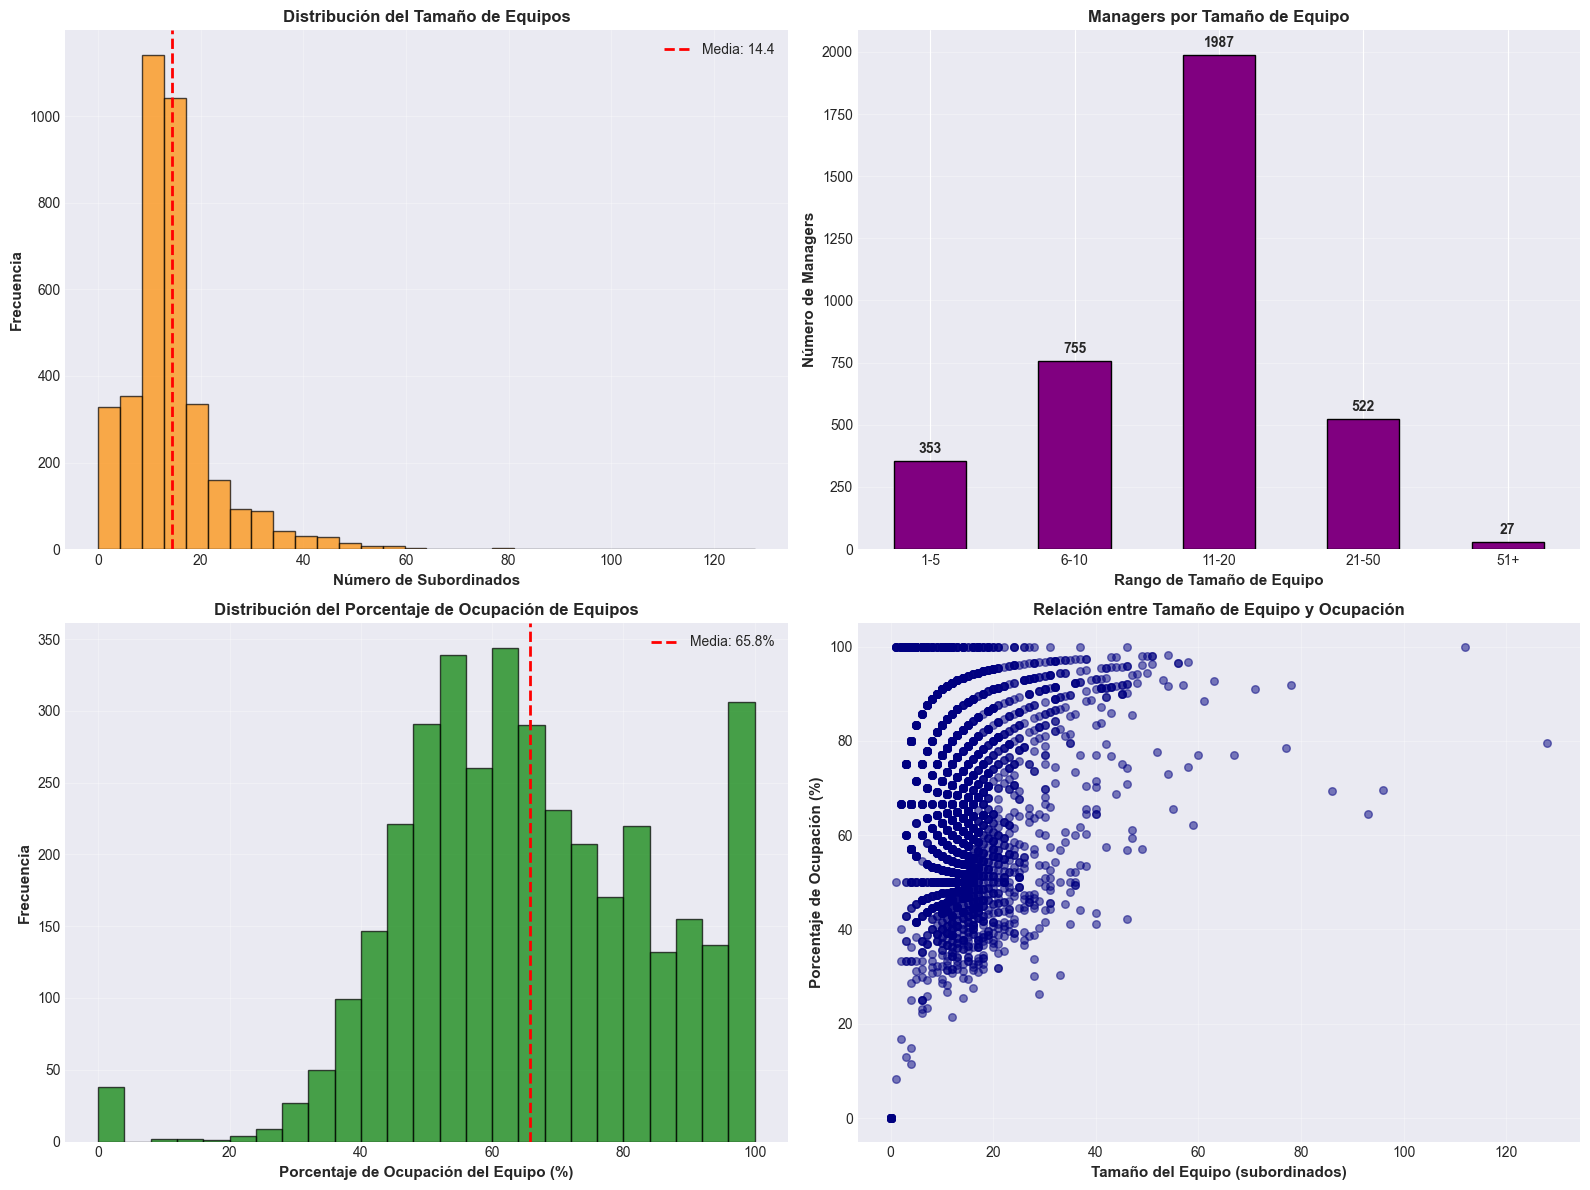


Observación:
El porcentaje promedio de ocupación de equipos es 65.8%.
El 7.3% de los equipos están completamente ocupados (100% de ocupación).


In [12]:
# Visualización de equipos
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Distribución tamaño de equipo
axes[0, 0].hist(managers_con_equipo['tamano_equipo'], bins=30, color='darkorange', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(managers_con_equipo['tamano_equipo'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {managers_con_equipo["tamano_equipo"].mean():.1f}')
axes[0, 0].set_xlabel('Número de Subordinados', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Distribución del Tamaño de Equipos', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Barras por rango
tamano_dist.plot(kind='bar', ax=axes[0, 1], color='purple', edgecolor='black')
axes[0, 1].set_xlabel('Rango de Tamaño de Equipo', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Número de Managers', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Managers por Tamaño de Equipo', fontsize=12, fontweight='bold')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=0)
axes[0, 1].grid(axis='y', alpha=0.3)

for i, v in enumerate(tamano_dist.values):
    axes[0, 1].text(i, v + 20, str(v), ha='center', va='bottom', fontweight='bold')

# Porcentaje de ocupación
axes[1, 0].hist(managers_con_equipo['pct_ocupacion_equipo'], bins=25, color='green', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(managers_con_equipo['pct_ocupacion_equipo'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {managers_con_equipo["pct_ocupacion_equipo"].mean():.1f}%')
axes[1, 0].set_xlabel('Porcentaje de Ocupación del Equipo (%)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Distribución del Porcentaje de Ocupación de Equipos', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Scatter: tamaño vs ocupación
axes[1, 1].scatter(managers_con_equipo['tamano_equipo'], managers_con_equipo['pct_ocupacion_equipo'], 
                   alpha=0.5, color='navy', s=30)
axes[1, 1].set_xlabel('Tamaño del Equipo (subordinados)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Porcentaje de Ocupación (%)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Relación entre Tamaño de Equipo y Ocupación', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nObservación:")
print(f"El porcentaje promedio de ocupación de equipos es {managers_con_equipo['pct_ocupacion_equipo'].mean():.1f}%.")
equipos_completos = (managers_con_equipo['pct_ocupacion_equipo'] == 100).sum()
pct_completos = (equipos_completos / len(managers_con_equipo)) * 100
print(f"El {pct_completos:.1f}% de los equipos están completamente ocupados (100% de ocupación).")

### 6.2. Análisis de Vacantes

In [13]:
# Análisis de vacantes
print("Análisis de Posiciones Vacantes:")
print("="*50)
print(f"Total plantilla autorizada:      {managers_con_equipo['total_plantilla_autorizada'].sum():,}")
print(f"Total posiciones vacantes:       {managers_con_equipo['posiciones_vacantes'].sum():,}")
print(f"Promedio vacantes por manager:   {managers_con_equipo['posiciones_vacantes'].mean():.2f}")
print(f"Porcentaje promedio de vacantes: {managers_con_equipo['pct_posiciones_vacantes'].mean():.2f}%")

# Managers con vacantes
managers_con_vacantes = managers_con_equipo[managers_con_equipo['posiciones_vacantes'] > 0]
pct_managers_vacantes = (len(managers_con_vacantes) / len(managers_con_equipo)) * 100
print(f"\nManagers con vacantes abiertas:  {len(managers_con_vacantes):,} ({pct_managers_vacantes:.1f}%)")

Análisis de Posiciones Vacantes:
Total plantilla autorizada:      84,752
Total posiciones vacantes:       52,899
Promedio vacantes por manager:   14.37
Porcentaje promedio de vacantes: 77.28%

Managers con vacantes abiertas:  3,644 (99.0%)


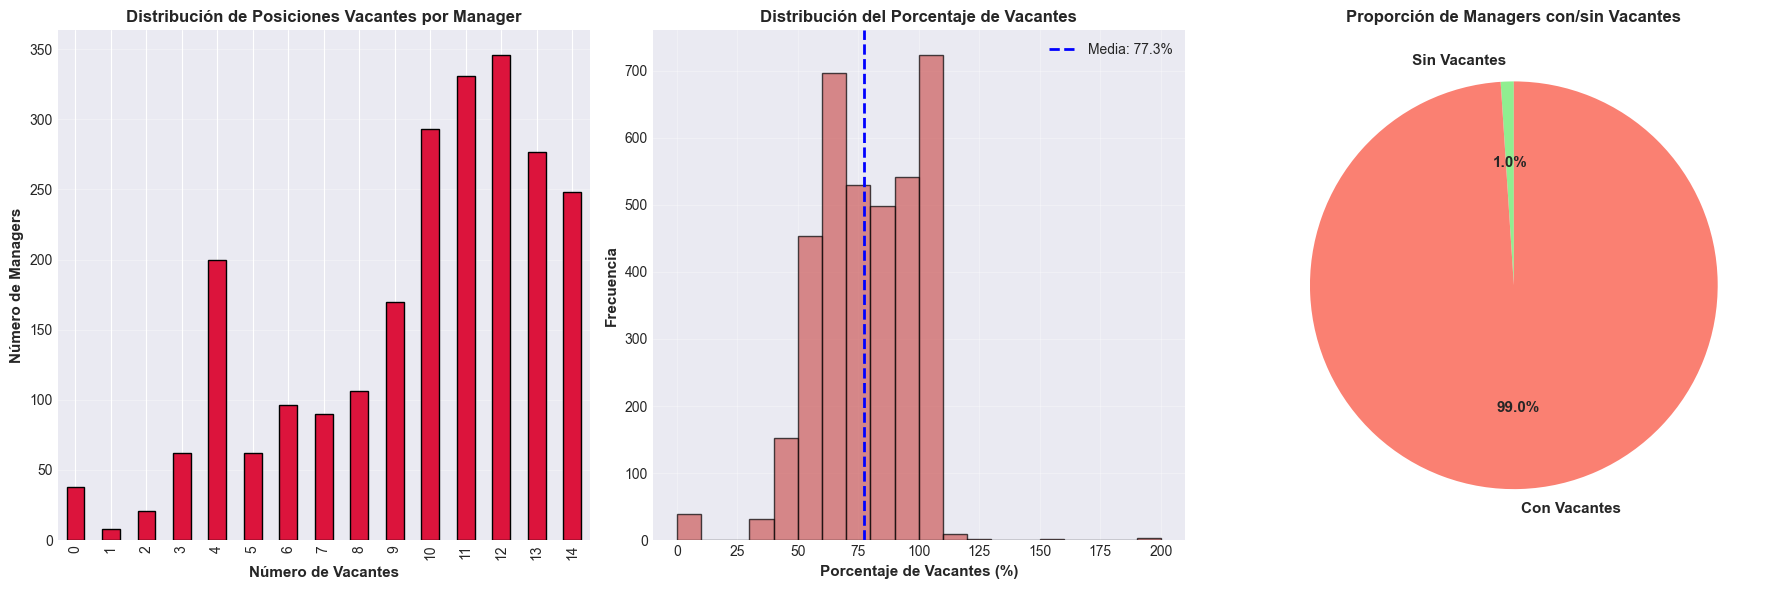


Observación:
El 99.0% de los managers tienen al menos una posición vacante en su equipo.


In [14]:
# Visualización de vacantes
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Distribución de vacantes
vacantes_data = managers_con_equipo['posiciones_vacantes'].value_counts().sort_index().head(15)
vacantes_data.plot(kind='bar', ax=axes[0], color='crimson', edgecolor='black')
axes[0].set_xlabel('Número de Vacantes', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Número de Managers', fontsize=11, fontweight='bold')
axes[0].set_title('Distribución de Posiciones Vacantes por Manager', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Porcentaje de vacantes
axes[1].hist(managers_con_equipo['pct_posiciones_vacantes'], bins=20, color='indianred', edgecolor='black', alpha=0.7)
axes[1].axvline(managers_con_equipo['pct_posiciones_vacantes'].mean(), color='blue', linestyle='--', linewidth=2, label=f'Media: {managers_con_equipo["pct_posiciones_vacantes"].mean():.1f}%')
axes[1].set_xlabel('Porcentaje de Vacantes (%)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
axes[1].set_title('Distribución del Porcentaje de Vacantes', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Comparación: con vacantes vs sin vacantes
vacantes_status = pd.Series([
    len(managers_con_equipo[managers_con_equipo['posiciones_vacantes'] == 0]),
    len(managers_con_equipo[managers_con_equipo['posiciones_vacantes'] > 0])
], index=['Sin Vacantes', 'Con Vacantes'])

vacantes_status.plot(kind='pie', ax=axes[2], autopct='%1.1f%%', colors=['lightgreen', 'salmon'],
                     startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[2].set_ylabel('')
axes[2].set_title('Proporción de Managers con/sin Vacantes', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nObservación:")
print(f"El {pct_managers_vacantes:.1f}% de los managers tienen al menos una posición vacante en su equipo.")

## 7. Análisis Organizacional

### 7.1. Distribución por empleado legal

In [15]:
# Top unidades de negocio
emp_legal_dist = df['empleador_legal'].value_counts()

print("Empleador Legal:")
print("="*60)
for unidad, count in emp_legal_dist.items():
    pct = (count / len(df)) * 100
    print(f"{unidad:30s}: {count:5d} ({pct:5.2f}%)")

Empleador Legal:
COPPEL SA DE CV               :  3755 (80.41%)
BANCOPPEL, S.A., INSTITUCION DE BANCA MÚLTIPLE:   876 (18.76%)
SAVAPRE S.A. DE C.V.          :    36 ( 0.77%)
AFORE COPPEL S.A. DE C.V.     :     3 ( 0.06%)


### 7.2. Distribución por Región Geográfica

In [16]:
# Top regiones
region_dist = df['region'].value_counts()

print("Regionescon Personal Entrevistado:")
print("="*60)
for region, count in region_dist.items():
    pct = (count / len(df)) * 100
    print(f"{region:30s}: {count:5d} ({pct:5.2f}%)")

Regionescon Personal Entrevistado:
TOLUCA                        :   398 ( 8.52%)
IZTAPALAPA                    :   351 ( 7.52%)
TORREON                       :   256 ( 5.48%)
IXTAPALUCA                    :   244 ( 5.22%)
MERIDA                        :   240 ( 5.14%)
MONTERREY II                  :   229 ( 4.90%)
MEXICALI                      :   217 ( 4.65%)
CUAUTITLAN IZCA               :   208 ( 4.45%)
AZCAPOTZALCO                  :   204 ( 4.37%)
PUEBLA                        :   190 ( 4.07%)
MONTERREY                     :   188 ( 4.03%)
SAN LUIS POTOSI               :   186 ( 3.98%)
PUEBLA II                     :   177 ( 3.79%)
HERMOSILLO                    :   177 ( 3.79%)
VILLAHERMOSA                  :   172 ( 3.68%)
OAXACA                        :   164 ( 3.51%)
TECAMAC                       :   163 ( 3.49%)
GUADALAJARA                   :   161 ( 3.45%)
GUADALAJARA II                :   123 ( 2.63%)
LEON                          :   116 ( 2.48%)
CD JUAREZ                

### 7.3. Distribución por Departamento

In [17]:
# Top departamentos
depto_dist = df['departamento'].value_counts().head(15)

print("Top 15 Departamentos:")
print("="*70)
for depto, count in depto_dist.items():
    pct = (count / len(df)) * 100
    print(f"{depto[:50]:50s}: {count:5d} ({pct:5.2f}%)")

Top 15 Departamentos:
06 IXTP SERVICIOS Y SOPORTE EN SITIO              :    28 ( 0.60%)
07 OPERACION DE COBRANZA VRCZ 06                  :    24 ( 0.51%)
07 OPERACION DE COBRANZA IZTP 18                  :    21 ( 0.45%)
05 CEDIS MUEBLES TJNA                             :    18 ( 0.39%)
07 OPERACION DE COBRANZA TOLC 13                  :    18 ( 0.39%)
07 OPERACION DE COBRANZA MRDA 17                  :    15 ( 0.32%)
05 OPERACION 03 TIENDA TRRN                       :    13 ( 0.28%)
07 TIENDA ROPA 1155 MADERO                        :    12 ( 0.26%)
07 TIENDA ROPA 6576 PLAZA TLATELOLCO              :    11 ( 0.24%)
07 TIENDA ROPA 1419 ARKANA                        :    10 ( 0.21%)
07 TIENDA MUEBLES 7845 SAYAGO                     :    10 ( 0.21%)
07 TIENDA MUEBLES 0840 LAGUNILLA                  :     9 ( 0.19%)
07 TIENDA MUEBLES 1365 JUAN FLORES                :     9 ( 0.19%)
07 TIENDA MUEBLES 1155 MADERO                     :     9 ( 0.19%)
07 TIENDA ROPA 0898 MOTOLINIA           

## 8. Análisis Comparativo: Escolaridad vs Antigüedad (entrevistado)

In [18]:
# Análisis cruzado
escolaridad_antiguedad = df.groupby('escolaridad')['antiguedad_anois'].agg(['mean', 'median', 'std', 'count']).round(2)
escolaridad_antiguedad = escolaridad_antiguedad.sort_values('mean', ascending=False)

print("Antigüedad promedio por Nivel de Escolaridad:")
print("="*80)
print(escolaridad_antiguedad)

Antigüedad promedio por Nivel de Escolaridad:
                                                    mean  median  std  count
escolaridad                                                                 
Carrera técnica, Maestría                          25.78   25.78  NaN      1
Preparatoria, Doctorado                            17.27   17.27  NaN      1
Maestría, Doctorado                                15.47   15.47  NaN      1
Preparatoria, Carrera técnica, Licenciatura o I... 12.83   10.33 6.58      5
Preparatoria, Carrera técnica                      10.65   10.19 7.31     28
Carrera técnica                                    10.45    9.52 6.70    227
Carrera técnica, Licenciatura o Ingeniería          9.58    7.98 6.12     20
Preparatoria, Licenciatura o Ingeniería             9.58    8.59 6.08     17
Maestría                                            8.96    7.51 6.11    355
Preparatoria, Carrera técnica, Licenciatura o I...  8.96    8.96  NaN      1
Preparatoria                  

## 9. Análisis de Indicadores de Rigidez y Gestión

In [19]:
# Análisis de rigidez de contratación
print("Análisis del Índice de Rigidez de Contratación:")
print("="*60)
print(f"Promedio:        {managers_con_equipo['indice_rigidez_contratacion'].mean():.4f}")
print(f"Mediana:         {managers_con_equipo['indice_rigidez_contratacion'].median():.4f}")
print(f"Desviación Est.: {managers_con_equipo['indice_rigidez_contratacion'].std():.4f}")
print(f"Máximo:          {managers_con_equipo['indice_rigidez_contratacion'].max():.4f}")

# Managers con alta rigidez (> 0.5)
alta_rigidez = managers_con_equipo[managers_con_equipo['indice_rigidez_contratacion'] > 0.5]
pct_alta_rigidez = (len(alta_rigidez) / len(managers_con_equipo)) * 100
print(f"\nManagers con alta rigidez (>0.5): {len(alta_rigidez)} ({pct_alta_rigidez:.1f}%)")

Análisis del Índice de Rigidez de Contratación:
Promedio:        0.3370
Mediana:         0.1875
Desviación Est.: 0.6848
Máximo:          16.0000

Managers con alta rigidez (>0.5): 702 (19.1%)


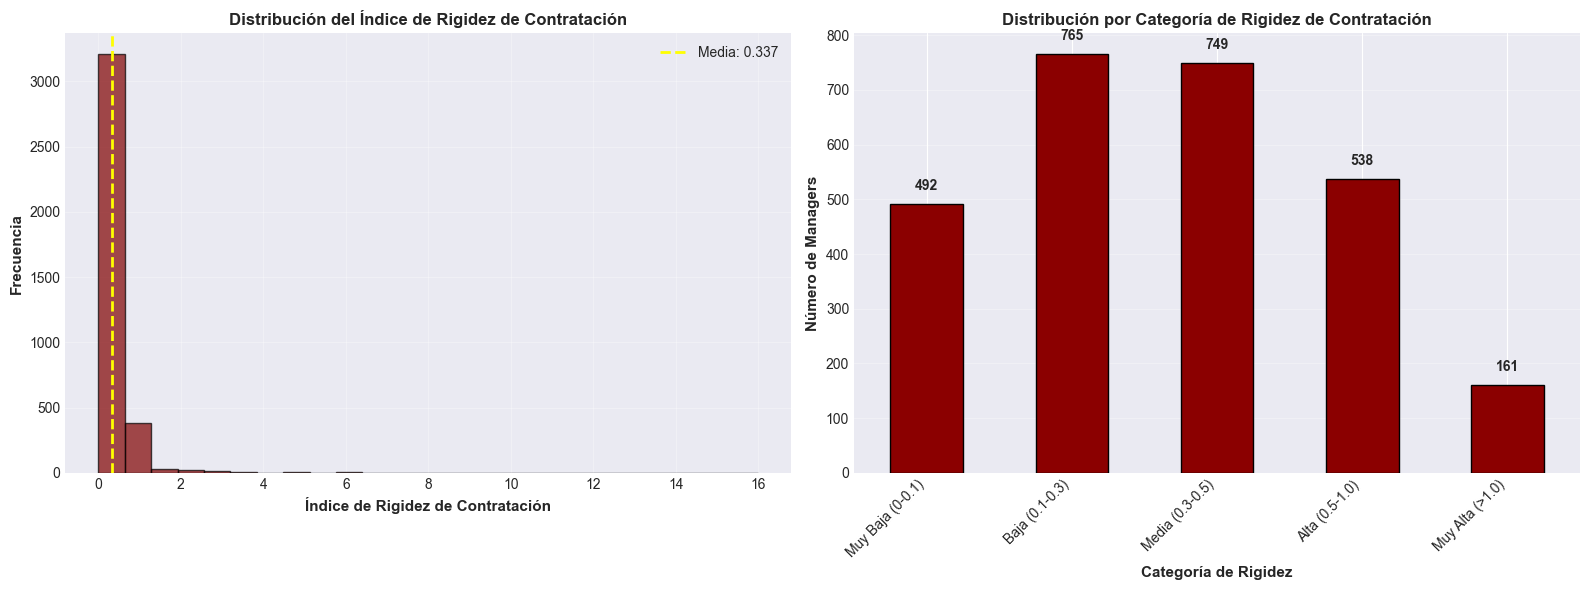

In [20]:
# Visualización de rigidez
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma
axes[0].hist(managers_con_equipo['indice_rigidez_contratacion'], bins=25, color='maroon', edgecolor='black', alpha=0.7)
axes[0].axvline(managers_con_equipo['indice_rigidez_contratacion'].mean(), color='yellow', linestyle='--', linewidth=2, label=f'Media: {managers_con_equipo["indice_rigidez_contratacion"].mean():.3f}')
axes[0].set_xlabel('Índice de Rigidez de Contratación', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
axes[0].set_title('Distribución del Índice de Rigidez de Contratación', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Categorización
rigidez_categorias = pd.cut(managers_con_equipo['indice_rigidez_contratacion'], 
                             bins=[0, 0.1, 0.3, 0.5, 1.0, 10],
                             labels=['Muy Baja (0-0.1)', 'Baja (0.1-0.3)', 'Media (0.3-0.5)', 'Alta (0.5-1.0)', 'Muy Alta (>1.0)'])
rigidez_dist = rigidez_categorias.value_counts().sort_index()

rigidez_dist.plot(kind='bar', ax=axes[1], color='darkred', edgecolor='black')
axes[1].set_xlabel('Categoría de Rigidez', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Número de Managers', fontsize=11, fontweight='bold')
axes[1].set_title('Distribución por Categoría de Rigidez de Contratación', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(rigidez_dist.values):
    axes[1].text(i, v + 20, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 10. Grupo Salarial
1. ```promedio_grupo_salarial``` 
1. ```std_grupo_salarial``` 
1. ```moda_grupo_salarial```


Análisis Comparativo: Grupo Salarial por Tamaño de Equipo
                 promedio_grupo_salarial             std_grupo_salarial  \
                                    mean median  std               mean   
cat_tamano                                                                
Pequeño (1-10)                      6.47   5.17 2.11               0.75   
Mediano (11-20)                     5.31   4.94 0.82               0.70   
Grande (21-30)                      5.85   5.72 1.09               1.11   
Muy Grande (31+)                    5.94   5.74 0.89               1.26   

                        tamano_equipo  
                 median         count  
cat_tamano                             
Pequeño (1-10)     0.50          1108  
Mediano (11-20)    0.47          1987  
Grande (21-30)     1.13           349  
Muy Grande (31+)   1.35           200  


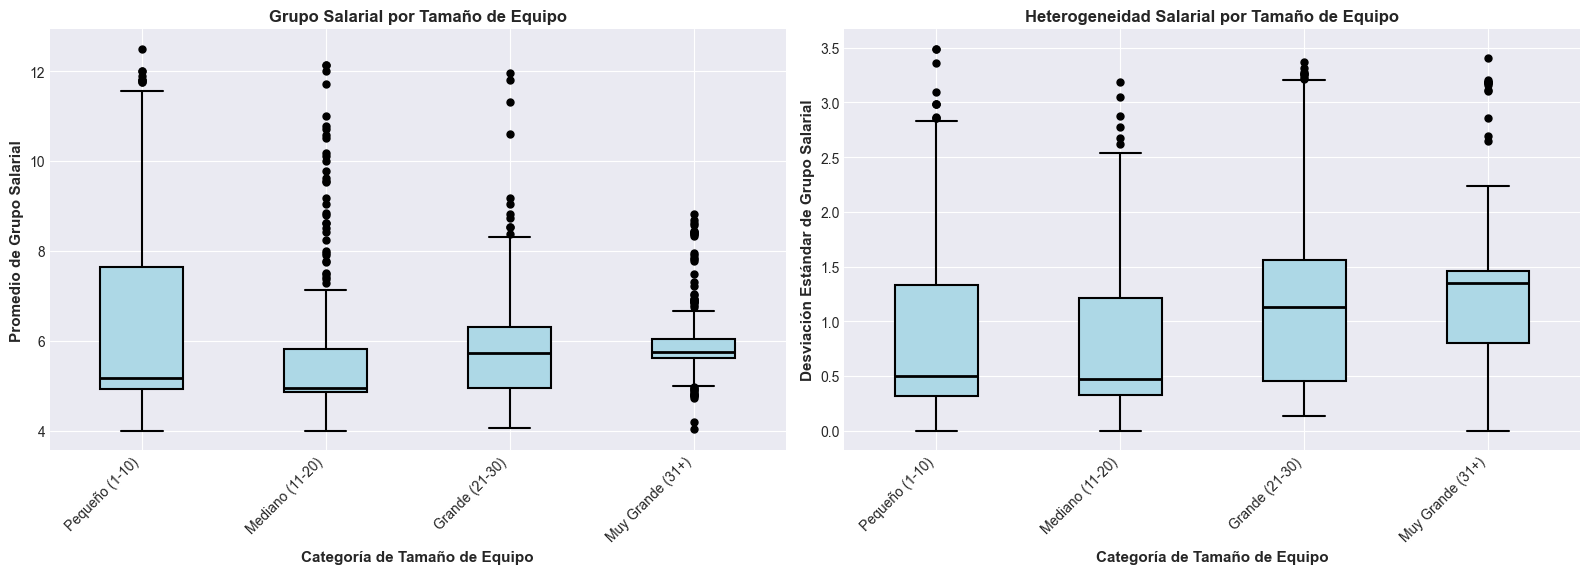

In [21]:
# Análisis comparativo: Grupo Salarial vs Tamaño de Equipo
print("\nAnálisis Comparativo: Grupo Salarial por Tamaño de Equipo")
print("="*70)

# Crear categorías de tamaño
managers_con_equipo['cat_tamano'] = pd.cut(managers_con_equipo['tamano_equipo'], 
                                            bins=[0, 10, 20, 30, 200],
                                            labels=['Pequeño (1-10)', 'Mediano (11-20)', 
                                                   'Grande (21-30)', 'Muy Grande (31+)'])

# Análisis por categoría
analisis_por_tamano = managers_con_equipo.groupby('cat_tamano').agg({
    'promedio_grupo_salarial': ['mean', 'median', 'std'],
    'std_grupo_salarial': ['mean', 'median'],
    'tamano_equipo': 'count'
}).round(2)

print(analisis_por_tamano)

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot por tamaño de equipo
managers_con_equipo.boxplot(
    column='promedio_grupo_salarial', 
    by='cat_tamano', 
    ax=axes[0],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='black', linewidth=1.5),
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5),
    flierprops=dict(marker='o', markerfacecolor='black', markersize=5, linestyle='none')
)
axes[0].set_xlabel('Categoría de Tamaño de Equipo', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Promedio de Grupo Salarial', fontsize=11, fontweight='bold')
axes[0].set_title('Grupo Salarial por Tamaño de Equipo', fontsize=12, fontweight='bold')
axes[0].get_figure().suptitle('')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Dispersión salarial por tamaño
managers_con_equipo.boxplot(
    column='std_grupo_salarial', 
    by='cat_tamano', 
    ax=axes[1],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='black', linewidth=1.5),
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5),
    flierprops=dict(marker='o', markerfacecolor='black', markersize=5, linestyle='none')
)
axes[1].set_xlabel('Categoría de Tamaño de Equipo', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Desviación Estándar de Grupo Salarial', fontsize=11, fontweight='bold')
axes[1].set_title('Heterogeneidad Salarial por Tamaño de Equipo', fontsize=12, fontweight='bold')
axes[1].get_figure().suptitle('')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()



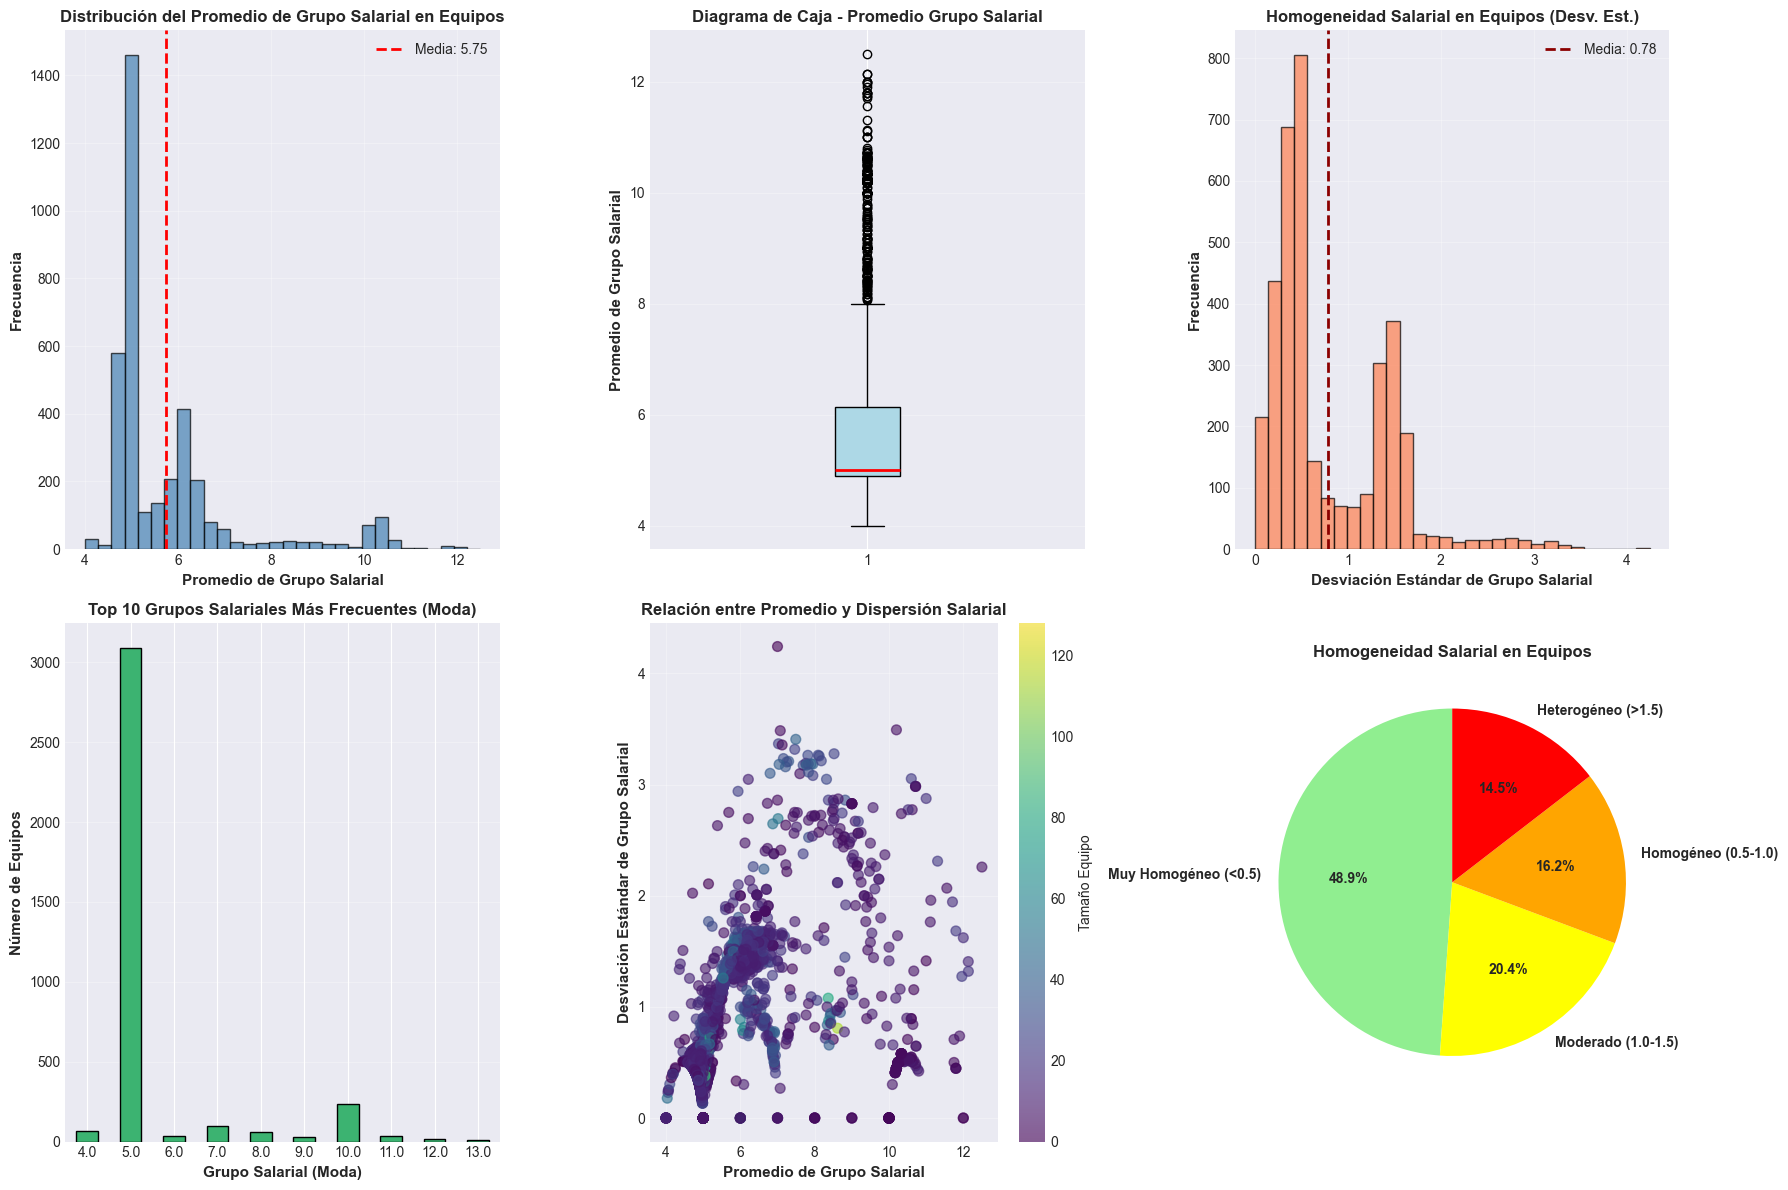


Observación:
El 66.5% de los equipos presentan alta homogeneidad salarial (desv. est. < 1.0).
Correlación entre promedio y dispersión salarial: 0.418


In [22]:
# Visualizaciones de Grupo Salarial
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Distribución del promedio de grupo salarial
axes[0, 0].hist(managers_con_equipo['promedio_grupo_salarial'].dropna(), bins=30, 
                color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(managers_con_equipo['promedio_grupo_salarial'].mean(), 
                   color='red', linestyle='--', linewidth=2, 
                   label=f'Media: {managers_con_equipo["promedio_grupo_salarial"].mean():.2f}')
axes[0, 0].set_xlabel('Promedio de Grupo Salarial', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Distribución del Promedio de Grupo Salarial en Equipos', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Box plot del promedio salarial
axes[0, 1].boxplot(managers_con_equipo['promedio_grupo_salarial'].dropna(), 
                   vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', edgecolor='black'),
                   medianprops=dict(color='red', linewidth=2),
                   whiskerprops=dict(color='black'),
                   capprops=dict(color='black'))
axes[0, 1].set_ylabel('Promedio de Grupo Salarial', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Diagrama de Caja - Promedio Grupo Salarial', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Distribución de la desviación estándar
axes[0, 2].hist(managers_con_equipo['std_grupo_salarial'].dropna(), bins=30, 
                color='coral', edgecolor='black', alpha=0.7)
axes[0, 2].axvline(managers_con_equipo['std_grupo_salarial'].mean(), 
                   color='darkred', linestyle='--', linewidth=2,
                   label=f'Media: {managers_con_equipo["std_grupo_salarial"].mean():.2f}')
axes[0, 2].set_xlabel('Desviación Estándar de Grupo Salarial', fontsize=11, fontweight='bold')
axes[0, 2].set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
axes[0, 2].set_title('Homogeneidad Salarial en Equipos (Desv. Est.)', fontsize=12, fontweight='bold')
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)

# 4. Distribución de la moda de grupo salarial
moda_dist_top10 = managers_con_equipo['moda_grupo_salarial'].value_counts().head(10).sort_index()
moda_dist_top10.plot(kind='bar', ax=axes[1, 0], color='mediumseagreen', edgecolor='black')
axes[1, 0].set_xlabel('Grupo Salarial (Moda)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Número de Equipos', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Top 10 Grupos Salariales Más Frecuentes (Moda)', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=0)

# 5. Relación entre promedio y desviación estándar salarial
scatter = axes[1, 1].scatter(managers_con_equipo['promedio_grupo_salarial'], 
                             managers_con_equipo['std_grupo_salarial'],
                             c=managers_con_equipo['tamano_equipo'], cmap='viridis', 
                             alpha=0.6, s=50)
axes[1, 1].set_xlabel('Promedio de Grupo Salarial', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Desviación Estándar de Grupo Salarial', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Relación entre Promedio y Dispersión Salarial', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[1, 1], label='Tamaño Equipo')

# 6. Categorización de homogeneidad salarial
managers_con_equipo['homogeneidad_salarial'] = pd.cut(managers_con_equipo['std_grupo_salarial'], 
                                                       bins=[0, 0.5, 1.0, 1.5, 10],
                                                       labels=['Muy Homogéneo (<0.5)', 
                                                              'Homogéneo (0.5-1.0)', 
                                                              'Moderado (1.0-1.5)', 
                                                              'Heterogéneo (>1.5)'])
homog_dist = managers_con_equipo['homogeneidad_salarial'].value_counts()
homog_dist.plot(kind='pie', ax=axes[1, 2], autopct='%1.1f%%', 
                colors=['lightgreen', 'yellow', 'orange', 'red'],
                startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
axes[1, 2].set_ylabel('')
axes[1, 2].set_title('Homogeneidad Salarial en Equipos', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nObservación:")
equipos_homogeneos = len(managers_con_equipo[managers_con_equipo['std_grupo_salarial'] < 1.0])
pct_homogeneos = (equipos_homogeneos / len(managers_con_equipo)) * 100
print(f"El {pct_homogeneos:.1f}% de los equipos presentan alta homogeneidad salarial (desv. est. < 1.0).")

# Análisis de correlación
correlacion = managers_con_equipo['promedio_grupo_salarial'].corr(managers_con_equipo['std_grupo_salarial'])
print(f"Correlación entre promedio y dispersión salarial: {correlacion:.3f}")

In [23]:
# Análisis de Grupo Salarial
print("Análisis de Grupos Salariales:")
print("="*70)

# Estadísticas descriptivas para managers con equipo
print("\nEstadísticas de Promedio de Grupo Salarial:")
print(f"Media:           {managers_con_equipo['promedio_grupo_salarial'].mean():.2f}")
print(f"Mediana:         {managers_con_equipo['promedio_grupo_salarial'].median():.2f}")
print(f"Desviación Est.: {managers_con_equipo['promedio_grupo_salarial'].std():.2f}")
print(f"Mínimo:          {managers_con_equipo['promedio_grupo_salarial'].min():.2f}")
print(f"Máximo:          {managers_con_equipo['promedio_grupo_salarial'].max():.2f}")

print("\nEstadísticas de Desviación Estándar de Grupo Salarial:")
print(f"Media:           {managers_con_equipo['std_grupo_salarial'].mean():.2f}")
print(f"Mediana:         {managers_con_equipo['std_grupo_salarial'].median():.2f}")
print(f"Mínimo:          {managers_con_equipo['std_grupo_salarial'].min():.2f}")
print(f"Máximo:          {managers_con_equipo['std_grupo_salarial'].max():.2f}")

print("\nEstadísticas de Moda de Grupo Salarial:")
print(f"Media:           {managers_con_equipo['moda_grupo_salarial'].mean():.2f}")
print(f"Mediana:         {managers_con_equipo['moda_grupo_salarial'].median():.2f}")
moda_dist = managers_con_equipo['moda_grupo_salarial'].value_counts().head(5)
print("\nTop 5 Modas más frecuentes:")
for moda, count in moda_dist.items():
    pct = (count / len(managers_con_equipo)) * 100
    print(f"  Grupo {moda:.0f}: {count:4d} equipos ({pct:5.2f}%)")

Análisis de Grupos Salariales:

Estadísticas de Promedio de Grupo Salarial:
Media:           5.75
Mediana:         5.00
Desviación Est.: 1.48
Mínimo:          4.00
Máximo:          12.50

Estadísticas de Desviación Estándar de Grupo Salarial:
Media:           0.78
Mediana:         0.50
Mínimo:          0.00
Máximo:          4.24

Estadísticas de Moda de Grupo Salarial:
Media:           5.56
Mediana:         5.00

Top 5 Modas más frecuentes:
  Grupo 5: 3092 equipos (83.98%)
  Grupo 10:  237 equipos ( 6.44%)
  Grupo 7:   95 equipos ( 2.58%)
  Grupo 4:   69 equipos ( 1.87%)
  Grupo 8:   63 equipos ( 1.71%)


## 11. Antiguedad de subordinados
Variables:
1. ```promedio_antiguedad_subordinados_anos```
1. ```std_antiguedad_equipo```           


Comparación: Antigüedad del Manager vs Antigüedad de su Equipo

Diferencia promedio de antigüedad: 5.69 años
Mediana de la diferencia: 5.16 años

Managers más antiguos que su equipo (>2 años): 2594 (70.5%)
Managers con antigüedad similar a su equipo (±2 años): 879 (23.9%)
Managers menos antiguos que su equipo (<-2 años): 170 (4.6%)


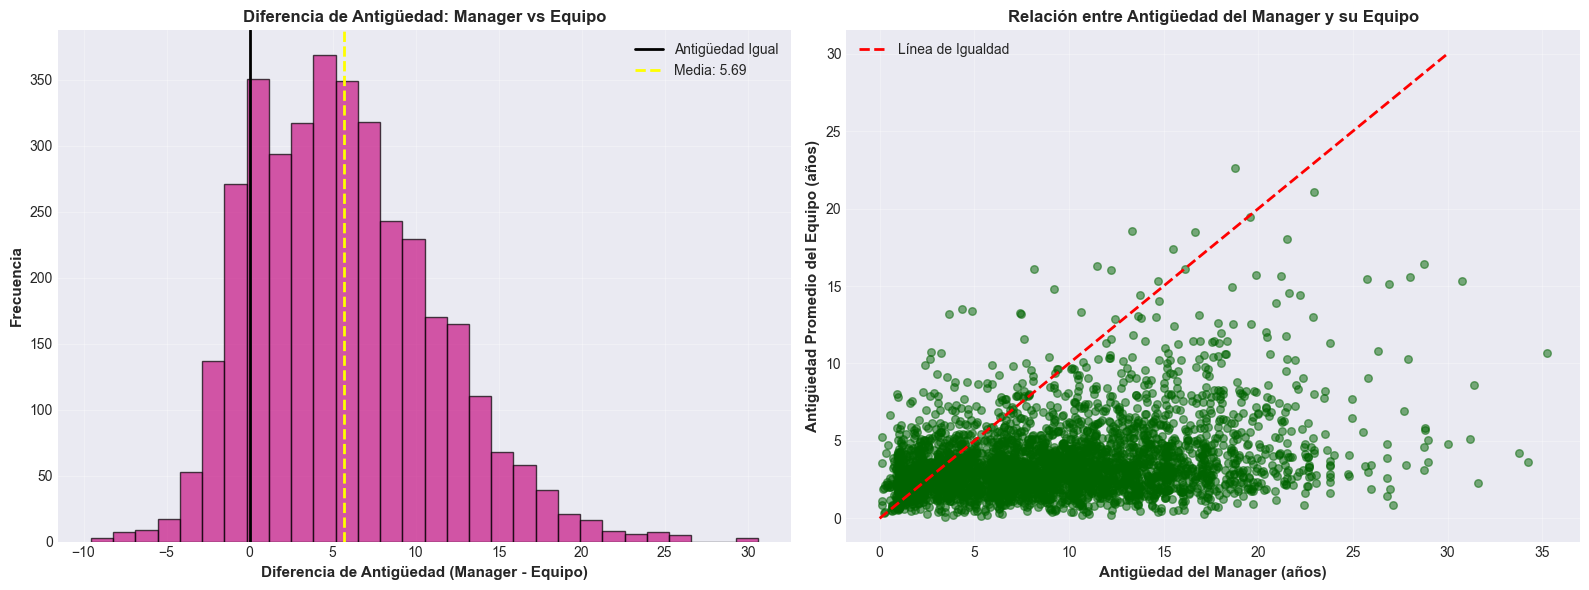

In [24]:
# Comparación: Antigüedad del Manager vs Antigüedad del Equipo
print("\nComparación: Antigüedad del Manager vs Antigüedad de su Equipo")
print("="*70)

# Crear variable comparativa
managers_con_equipo['diferencia_antiguedad'] = (managers_con_equipo['antiguedad_anois'] - 
                                                 managers_con_equipo['promedio_antiguedad_subordinados_anos'])

print(f"\nDiferencia promedio de antigüedad: {managers_con_equipo['diferencia_antiguedad'].mean():.2f} años")
print(f"Mediana de la diferencia: {managers_con_equipo['diferencia_antiguedad'].median():.2f} años")

# Clasificar managers
managers_mas_antiguos = (managers_con_equipo['diferencia_antiguedad'] > 2).sum()
managers_similar = ((managers_con_equipo['diferencia_antiguedad'] >= -2) & 
                    (managers_con_equipo['diferencia_antiguedad'] <= 2)).sum()
managers_menos_antiguos = (managers_con_equipo['diferencia_antiguedad'] < -2).sum()

total = len(managers_con_equipo)
print(f"\nManagers más antiguos que su equipo (>2 años): {managers_mas_antiguos} ({(managers_mas_antiguos/total)*100:.1f}%)")
print(f"Managers con antigüedad similar a su equipo (±2 años): {managers_similar} ({(managers_similar/total)*100:.1f}%)")
print(f"Managers menos antiguos que su equipo (<-2 años): {managers_menos_antiguos} ({(managers_menos_antiguos/total)*100:.1f}%)")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma de diferencia
axes[0].hist(managers_con_equipo['diferencia_antiguedad'], bins=30, 
             color='mediumvioletred', edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='black', linestyle='-', linewidth=2, label='Antigüedad Igual')
axes[0].axvline(managers_con_equipo['diferencia_antiguedad'].mean(), 
                color='yellow', linestyle='--', linewidth=2,
                label=f'Media: {managers_con_equipo["diferencia_antiguedad"].mean():.2f}')
axes[0].set_xlabel('Diferencia de Antigüedad (Manager - Equipo)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
axes[0].set_title('Diferencia de Antigüedad: Manager vs Equipo', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Scatter plot
axes[1].scatter(managers_con_equipo['antiguedad_anois'], 
                managers_con_equipo['promedio_antiguedad_subordinados_anos'],
                alpha=0.5, color='darkgreen', s=30)
axes[1].plot([0, 30], [0, 30], 'r--', linewidth=2, label='Línea de Igualdad')
axes[1].set_xlabel('Antigüedad del Manager (años)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Antigüedad Promedio del Equipo (años)', fontsize=11, fontweight='bold')
axes[1].set_title('Relación entre Antigüedad del Manager y su Equipo', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

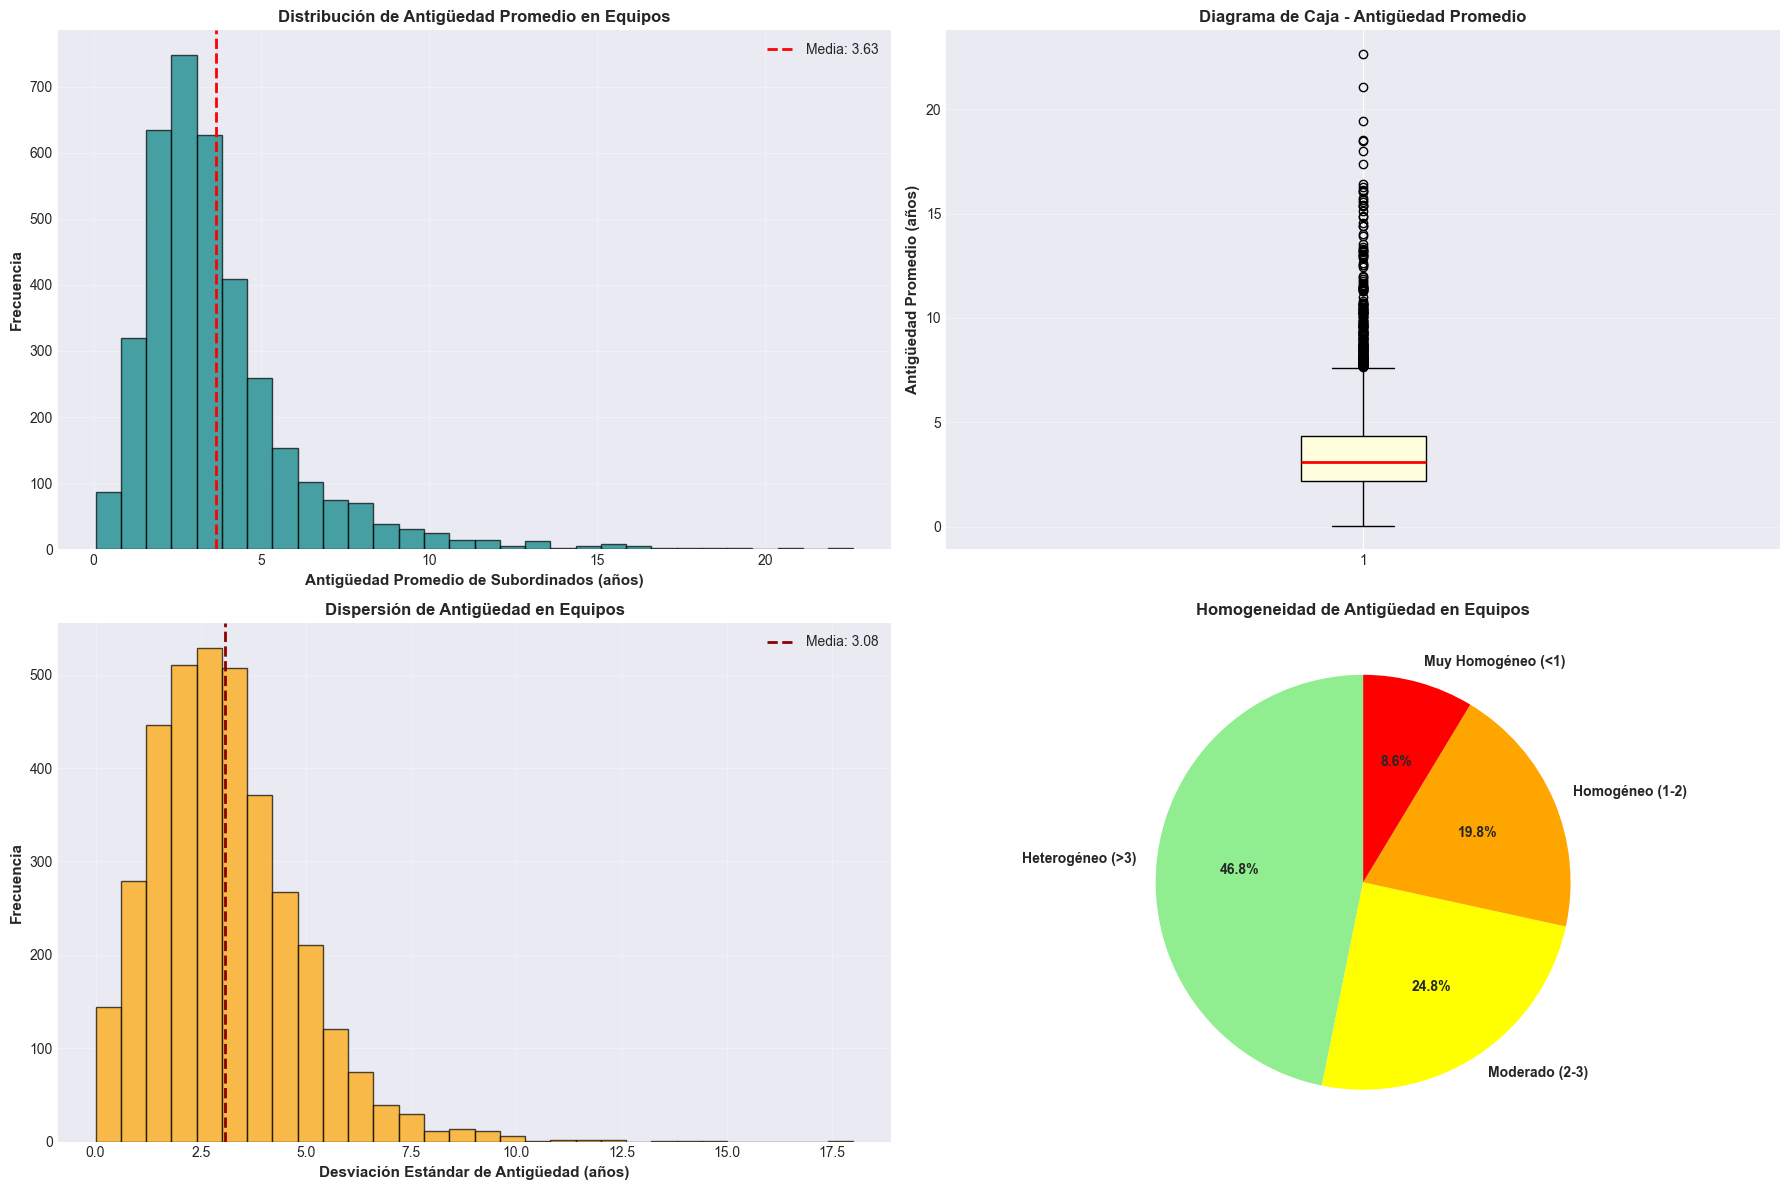

In [25]:
# Visualizaciones de Antigüedad de Subordinados
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Distribución del promedio de antigüedad
axes[0, 0].hist(managers_con_equipo['promedio_antiguedad_subordinados_anos'].dropna(), 
                bins=30, color='teal', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(managers_con_equipo['promedio_antiguedad_subordinados_anos'].mean(), 
                   color='red', linestyle='--', linewidth=2,
                   label=f'Media: {managers_con_equipo["promedio_antiguedad_subordinados_anos"].mean():.2f}')
axes[0, 0].set_xlabel('Antigüedad Promedio de Subordinados (años)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Distribución de Antigüedad Promedio en Equipos', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Box plot de antigüedad promedio
axes[0, 1].boxplot(managers_con_equipo['promedio_antiguedad_subordinados_anos'].dropna(), 
                   vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightyellow', edgecolor='black'),
                   medianprops=dict(color='red', linewidth=2),
                   whiskerprops=dict(color='black'),
                   capprops=dict(color='black'))
axes[0, 1].set_ylabel('Antigüedad Promedio (años)', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Diagrama de Caja - Antigüedad Promedio', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Distribución de desviación estándar de antigüedad
axes[1, 0].hist(managers_con_equipo['std_antiguedad_equipo'].dropna(), bins=30, 
                color='orange', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(managers_con_equipo['std_antiguedad_equipo'].mean(), 
                   color='darkred', linestyle='--', linewidth=2,
                   label=f'Media: {managers_con_equipo["std_antiguedad_equipo"].mean():.2f}')
axes[1, 0].set_xlabel('Desviación Estándar de Antigüedad (años)', fontsize=11, fontweight='bold')
axes[1, 0]  .set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Dispersión de Antigüedad en Equipos', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)


# 4. Homogeneidad de antigüedad
managers_con_equipo['homogeneidad_antiguedad'] = pd.cut(managers_con_equipo['std_antiguedad_equipo'], 
                                                         bins=[0, 1, 2, 3, 100],
                                                         labels=['Muy Homogéneo (<1)', 
                                                                'Homogéneo (1-2)', 
                                                                'Moderado (2-3)', 
                                                                'Heterogéneo (>3)'])
homog_ant_dist = managers_con_equipo['homogeneidad_antiguedad'].value_counts()
homog_ant_dist.plot(kind='pie', ax=axes[1, 1], autopct='%1.1f%%',
                    colors=['lightgreen', 'yellow', 'orange', 'red'],
                    startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
axes[1, 1].set_ylabel('')
axes[1, 1].set_title('Homogeneidad de Antigüedad en Equipos', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


In [26]:
# Análisis de Antigüedad de Subordinados
print("Análisis de Antigüedad de los Subordinados:")
print("="*70)

# Estadísticas descriptivas
print("\nPromedio de Antigüedad de Subordinados:")
print(f"Media:           {managers_con_equipo['promedio_antiguedad_subordinados_anos'].mean():.2f} años")
print(f"Mediana:         {managers_con_equipo['promedio_antiguedad_subordinados_anos'].median():.2f} años")
print(f"Desviación Est.: {managers_con_equipo['promedio_antiguedad_subordinados_anos'].std():.2f} años")
print(f"Mínimo:          {managers_con_equipo['promedio_antiguedad_subordinados_anos'].min():.2f} años")
print(f"Máximo:          {managers_con_equipo['promedio_antiguedad_subordinados_anos'].max():.2f} años")

print("\nDesviación Estándar de Antigüedad en Equipos:")
print(f"Media:           {managers_con_equipo['std_antiguedad_equipo'].mean():.2f} años")
print(f"Mediana:         {managers_con_equipo['std_antiguedad_equipo'].median():.2f} años")
print(f"Mínimo:          {managers_con_equipo['std_antiguedad_equipo'].min():.2f} años")
print(f"Máximo:          {managers_con_equipo['std_antiguedad_equipo'].max():.2f} años")

# Categorización de antigüedad promedio de subordinados
managers_con_equipo['cat_antiguedad_sub'] = pd.cut(managers_con_equipo['promedio_antiguedad_subordinados_anos'], 
                                                     bins=[0, 2, 4, 6, 100],
                                                     labels=['Junior (0-2 años)', 
                                                            'Intermedio (2-4 años)', 
                                                            'Senior (4-6 años)', 
                                                            'Muy Senior (6+ años)'])

antiguedad_sub_dist = managers_con_equipo['cat_antiguedad_sub'].value_counts().sort_index()
print("\nDistribución de Equipos por Antigüedad Promedio de Subordinados:")
print("="*70)
for cat, count in antiguedad_sub_dist.items():
    pct = (count / len(managers_con_equipo)) * 100
    print(f"{cat:25s}: {count:4d} equipos ({pct:5.2f}%)")

Análisis de Antigüedad de los Subordinados:

Promedio de Antigüedad de Subordinados:
Media:           3.63 años
Mediana:         3.11 años
Desviación Est.: 2.33 años
Mínimo:          0.06 años
Máximo:          22.64 años

Desviación Estándar de Antigüedad en Equipos:
Media:           3.08 años
Mediana:         2.87 años
Mínimo:          0.00 años
Máximo:          18.01 años

Distribución de Equipos por Antigüedad Promedio de Subordinados:
Junior (0-2 años)        :  757 equipos (20.56%)
Intermedio (2-4 años)    : 1775 equipos (48.21%)
Senior (4-6 años)        :  691 equipos (18.77%)
Muy Senior (6+ años)     :  420 equipos (11.41%)


## 12. Tipo de puesto del entrevistado 
Variables:
1. ```nombre_de_posicion```

In [27]:
# Análisis de Tipo de Puesto del Entrevistado
print("Análisis de Tipos de Puesto de los Entrevistados:")
print("="*70)

# Top 20 puestos más frecuentes
nombre_posicion_dist = df['nombre_de_posicion'].value_counts()

print("\n Posiciones más Frecuentes:")
print("="*70)
for i, (posicion, count) in enumerate(nombre_posicion_dist.items(), 1):
    pct = (count / len(df)) * 100
    print(f"{i:2d}. {posicion[:45]:45s}: {count:4d} ({pct:5.2f}%)")

# Análisis de concentración
print(f"\nTotal de tipos de posiciones únicas: {df['nombre_de_posicion'].nunique()}")
concentracion_top10 = (nombre_posicion_dist.head(10).sum() / len(df)) * 100
print(f"Concentración en Top 10 posiciones: {concentracion_top10:.1f}%")
concentracion_top20 = (nombre_posicion_dist.head(20).sum() / len(df)) * 100
print(f"Concentración en Top 20 posiciones: {concentracion_top20:.1f}%")
concentracion_top30 = (nombre_posicion_dist.head(30).sum() / len(df)) * 100
print(f"Concentración en Top 30 posiciones: {concentracion_top30:.1f}%")

Análisis de Tipos de Puesto de los Entrevistados:

 Posiciones más Frecuentes:
 1. GERENTE DE TIENDA ROPA                       : 1081 (23.15%)
 2. GERENTE DE TIENDA MUEBLES                    :  781 (16.72%)
 3. GERENTE DE SERVICIOS FINANCIEROS             :  678 (14.52%)
 4. GERENTE SUPLENTE                             :  618 (13.23%)
 5. GERENTE DE OPERACION COBRANZA                :  306 ( 6.55%)
 6. GERENTE GENERAL DE TIENDA                    :  140 ( 3.00%)
 7. GERENTE DE TIENDA MOTOS                      :   90 ( 1.93%)
 8. GERENTE DE AREA CEDIS                        :   86 ( 1.84%)
 9. GERENTE DE DISTRIBUCION                      :   70 ( 1.50%)
10. GERENTE DE ZONA SERVICIOS FINANCIEROS        :   60 ( 1.28%)
11. SUPERVISOR DE COBRANZA                       :   46 ( 0.99%)
12. SUBGERENTE DE SERVICIOS FINANCIEROS          :   37 ( 0.79%)
13. ENTRENAMIENTO DE BANCO                       :   37 ( 0.79%)
14. GERENTE DE ZONA TIENDA                       :   34 ( 0.73%)
15. GERENTE


Análisis por Nivel Jerárquico Implícito en el Nombre de Posición

Distribución por Nivel Jerárquico:
Medio - Gerencia/Jefatura               : 4214 (90.24%)
Operativo - Especialista                :  233 ( 4.99%)
Alto - Gerencia General/Dirección       :  142 ( 3.04%)
Intermedio - Coordinación/Supervisión   :   65 ( 1.39%)
Operativo - Soporte                     :   16 ( 0.34%)

Antigüedad por Nivel Jerárquico:
                                       mean  median  count
nivel_jerarquico                                          
Alto - Gerencia General/Dirección     12.54   12.67    142
Medio - Gerencia/Jefatura              8.73    7.99   4214
Operativo - Soporte                    6.03    2.93     16
Intermedio - Coordinación/Supervisión  3.99    2.17     65
Operativo - Especialista               3.54    2.29    233


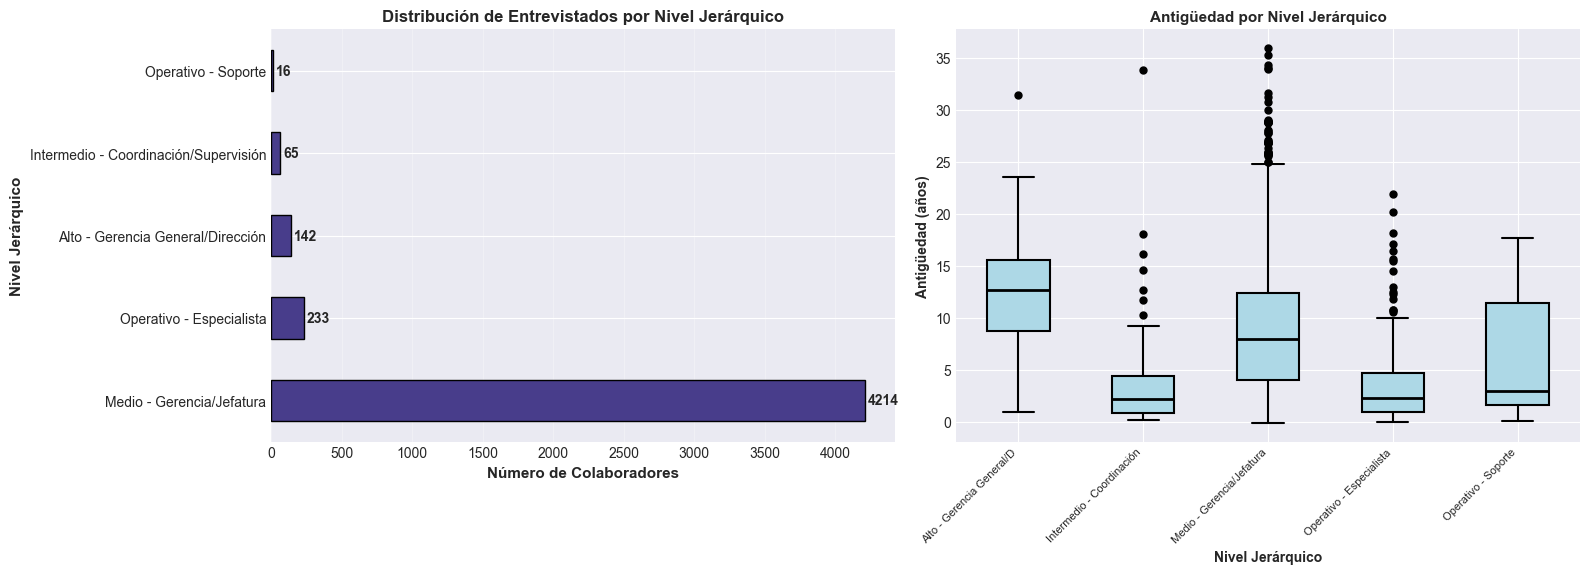

In [28]:
# Análisis de Posiciones por Nivel Jerárquico
print("\nAnálisis por Nivel Jerárquico Implícito en el Nombre de Posición")
print("="*70)

# Identificar palabras clave jerárquicas
def clasificar_nivel_jerarquico(posicion):
    posicion_upper = str(posicion).upper()
    if 'GERENTE GENERAL' in posicion_upper or 'DIRECTOR' in posicion_upper:
        return 'Alto - Gerencia General/Dirección'
    elif 'GERENTE' in posicion_upper or 'JEFE' in posicion_upper:
        return 'Medio - Gerencia/Jefatura'
    elif 'COORDINADOR' in posicion_upper or 'SUPERVISOR' in posicion_upper:
        return 'Intermedio - Coordinación/Supervisión'
    elif 'SUPLENTE' in posicion_upper or 'ASISTENTE' in posicion_upper or 'AUXILIAR' in posicion_upper:
        return 'Operativo - Soporte'
    else:
        return 'Operativo - Especialista'

df['nivel_jerarquico'] = df['nombre_de_posicion'].apply(clasificar_nivel_jerarquico)

nivel_dist = df['nivel_jerarquico'].value_counts()
print("\nDistribución por Nivel Jerárquico:")
for nivel, count in nivel_dist.items():
    pct = (count / len(df)) * 100
    print(f"{nivel:40s}: {count:4d} ({pct:5.2f}%)")

# Análisis de antigüedad por nivel
antiguedad_por_nivel = df.groupby('nivel_jerarquico')['antiguedad_anois'].agg([
    'mean', 'median', 'count'
]).round(2).sort_values('mean', ascending=False)

print("\nAntigüedad por Nivel Jerárquico:")
print(antiguedad_por_nivel)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribución por nivel
nivel_dist.plot(kind='barh', ax=axes[0], color='darkslateblue', edgecolor='black')
axes[0].set_xlabel('Número de Colaboradores', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Nivel Jerárquico', fontsize=11, fontweight='bold')
axes[0].set_title('Distribución de Entrevistados por Nivel Jerárquico', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

for i, v in enumerate(nivel_dist.values):
    axes[0].text(v + 20, i, str(v), va='center', fontweight='bold')

# Box plot de antigüedad por nivel
df.boxplot(
    column='antiguedad_anois',
    by='nivel_jerarquico',
    ax=axes[1],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='black', linewidth=1.5),
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5),
    flierprops=dict(marker='o', markerfacecolor='black', markersize=5, linestyle='none')
)

# Ajustes de etiquetas y títulos (tu código original)
axes[1].set_xlabel('Nivel Jerárquico', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Antigüedad (años)', fontsize=10, fontweight='bold')
axes[1].set_title('Antigüedad por Nivel Jerárquico', fontsize=11, fontweight='bold')
axes[1].get_figure().suptitle('') # Elimina el título extra que añade Pandas
axes[1].set_xticklabels([label.get_text()[:25] for label in axes[1].get_xticklabels()], 
                        rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

## Fin de EDA

**Autor**: José Eduardo Rodriguez Barrios 

**Versión**: 1.0  

**Herramientas**: Python 3.11, pandas, numpy, matplotlib, seaborn
